In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [46]:
ct_path = Path(r"E:\ProyectoAnalisisElectrico\CupraThermV2\Resumen_Establecimientos.csv")
dfy_path = Path(r"E:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2505_2604\2505_2604_mean_period_loc.parquet")
dfo_path = Path(r"E:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2505_2604_otono\2505_2604_otono_mean_period.parquet")
dfi_path = Path(r"E:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2507_2509_invierno\2507_2509_invierno_mean_period.parquet")
dfp_path = Path(r"E:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2510_2512_primavera\2510_2512_primavera_mean_period.parquet")
dfv_path = Path(r"E:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2601_2603_verano\2601_2603_verano_mean_period.parquet")

ct = pd.read_csv(ct_path,sep=",")
dfy = pd.read_parquet(dfy_path)
dfo = pd.read_parquet(dfo_path)
dfi = pd.read_parquet(dfi_path)
dfv = pd.read_parquet(dfv_path)
dfp = pd.read_parquet(dfp_path)
dfs = [dfy,dfo,dfi,dfv,dfp]

In [38]:
#rut = "76.858.530-K"
rut = "87.756.500-9"

In [39]:
claves_check = dfy[dfy["RUT"] == rut]["clave"].unique()


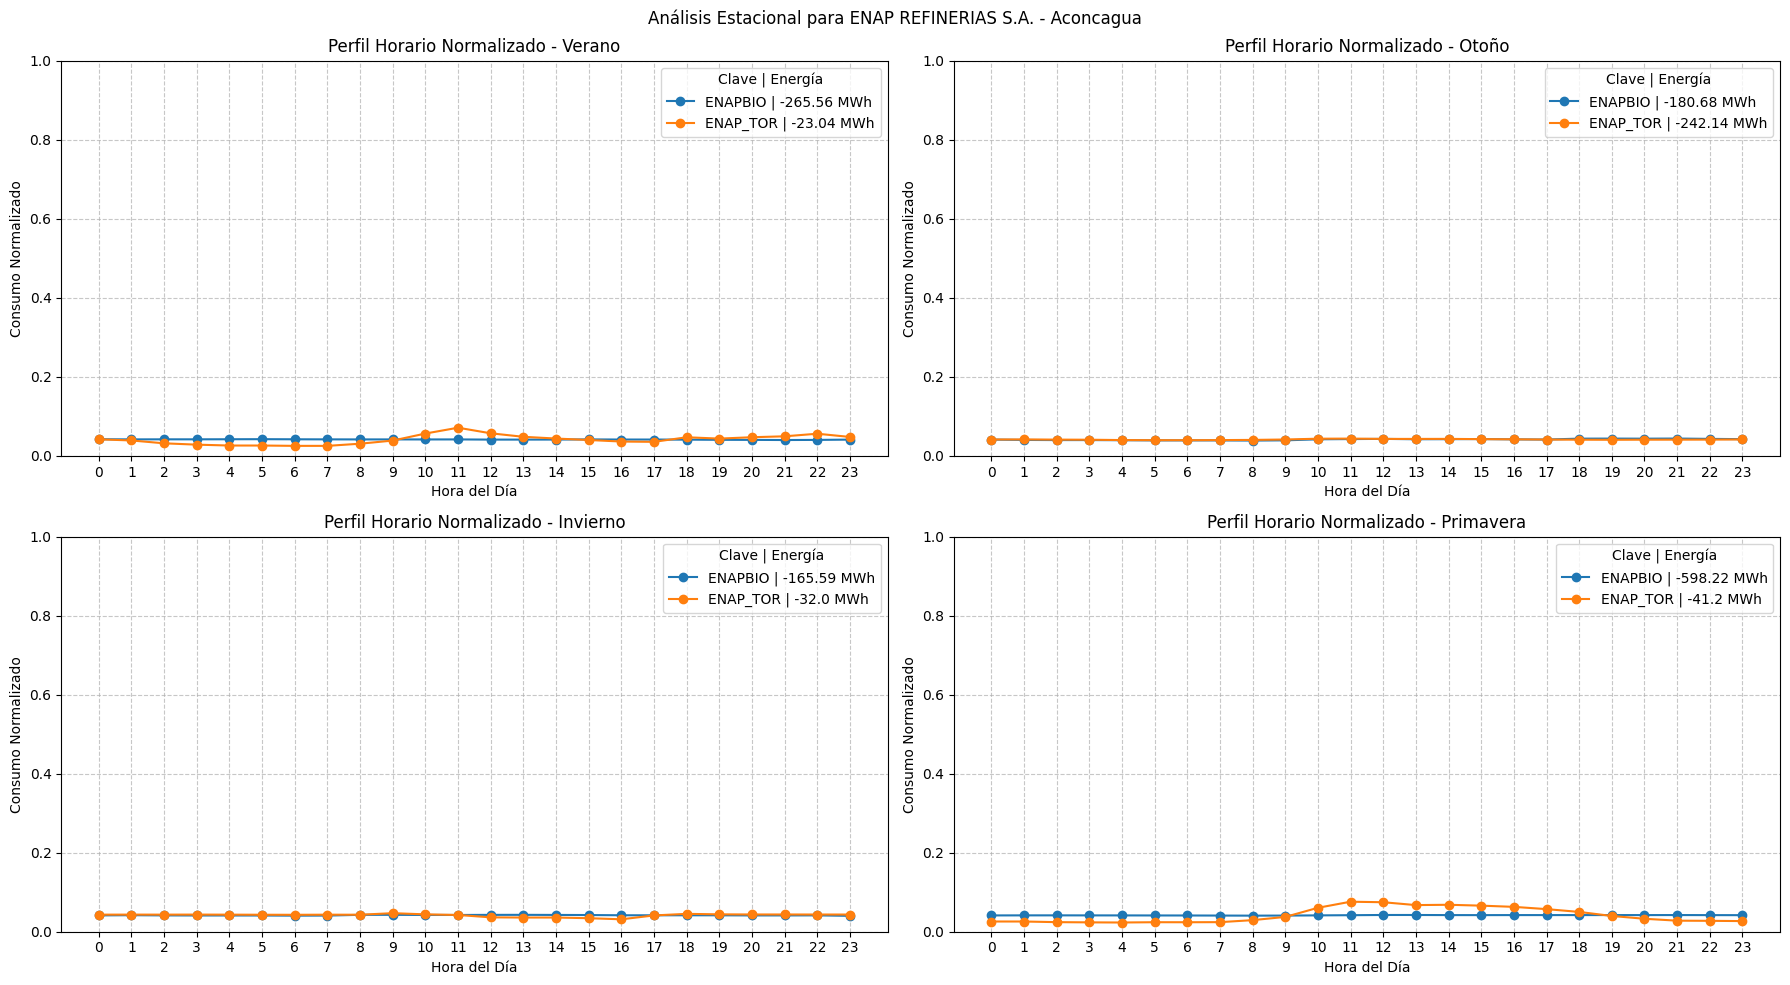

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

estaciones = [
    (dfv, "Verano", axes[0, 0]),
    (dfo, "Otoño", axes[0, 1]),
    (dfi, "Invierno", axes[1, 0]),
    (dfp, "Primavera", axes[1, 1])
]

for df_estacion, nombre, ax in estaciones:
    for clave in claves_check:
        df_clave = df_estacion[(df_estacion["RUT"] == rut) & (df_estacion["clave"] == clave)].sort_values("Hora")
        
        if not df_clave.empty:
            horas = df_clave["Hora"]
            datos_horarios = df_clave["medida_mean"] 
            total = datos_horarios.sum()
            
            datos_normalizados = datos_horarios / total
            
            ax.plot(horas, datos_normalizados, label=f"{clave} | {round(total/1000,2)} MWh", marker='o')

    ax.set_title(f"Perfil Horario Normalizado - {nombre}")
    ax.set_xlabel("Hora del Día")
    ax.set_ylabel("Consumo Normalizado")
    ax.legend(title="Clave | Energía")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(range(0, 24))
    ax.set_ylim(0, 1)

plt.suptitle(f"Análisis Estacional para {dfy[dfy["RUT"] == rut]["Razon_Social"].drop_duplicates().iloc[0]}")
plt.tight_layout()
plt.show()

In [50]:
dfy[dfy["RUT"] == rut].drop_duplicates(subset=["clave"])["nombre_barra"]

93648    PETROPOWER
93696    TORQUEMADA
Name: nombre_barra, dtype: str